Здесь мы соберем инфо по датам на которые потом будут прогнозы классификации от собственной модели (это все нулевые дни ниже), все остальные дни делятся на 2 части - до 10.10.2025 - это трейн, который был размечен вручную, и все не нулевые дни после этой даты - по прогнозам с помощью yandexgpt.

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
data_download = pd.read_parquet('prod/data_download_pre_mass_insert.parquet')

In [3]:
data_download.head()

,id,account_id,contractor_id,date,payments_amount,purpose,article_id,expenditure,project_id,counterpartie_id,...,projects__parent_id,projects__name,counterparties__id,counterparties__user_id,counterparties__parent_id,counterparties__name,robots__id,robots__user_id,article_alternative_names__user_id,uc__uc_id
0,289,1,70,2022-09-08,1.0,None,0,incoming,0,0,...,NaN,None,NaN,NaN,NaN,None,NaN,NaN,NaN,NaN
1,290,1,71,2022-09-08,1.0,None,0,incoming,0,0,...,NaN,None,NaN,NaN,NaN,None,NaN,NaN,NaN,NaN
2,291,1,30,2022-09-08,1.0,None,0,incoming,0,0,...,NaN,None,NaN,NaN,NaN,None,NaN,NaN,NaN,NaN
3,295,1,72,2022-09-08,1.0,None,0,incoming,0,0,...,NaN,None,NaN,NaN,NaN,None,NaN,NaN,NaN,NaN
4,304,5,29,2022-09-19,1.0,None,301,incoming,13,0,...,11.0,Проект 2,NaN,NaN,NaN,None,NaN,NaN,NaN,9.0


In [4]:
data_download['date'] = pd.to_datetime(
    data_download['date'],
    format='%Y-%m-%d',
    errors='coerce'   # ← некорректные даты станут NaT
).dt.date

today = pd.Timestamp.today().normalize()

# удаляем будущие даты
data_download = data_download[data_download['date'] <= today]

data_download.sort_values('date', inplace=True)

data_download['date'].nunique()


/var/folders/yf/tnhxwgts2035718d0nhj30rw0000gn/T/ipykernel_32386/3700420908.py:10: FutureWarning: Comparison of Timestamp with datetime.date is deprecated in order to match the standard library behavior. In a future version these will be considered non-comparable. Use 'ts == pd.Timestamp(date)' or 'ts.date() == date' instead.
  data_download = data_download[data_download['date'] <= today]


2017

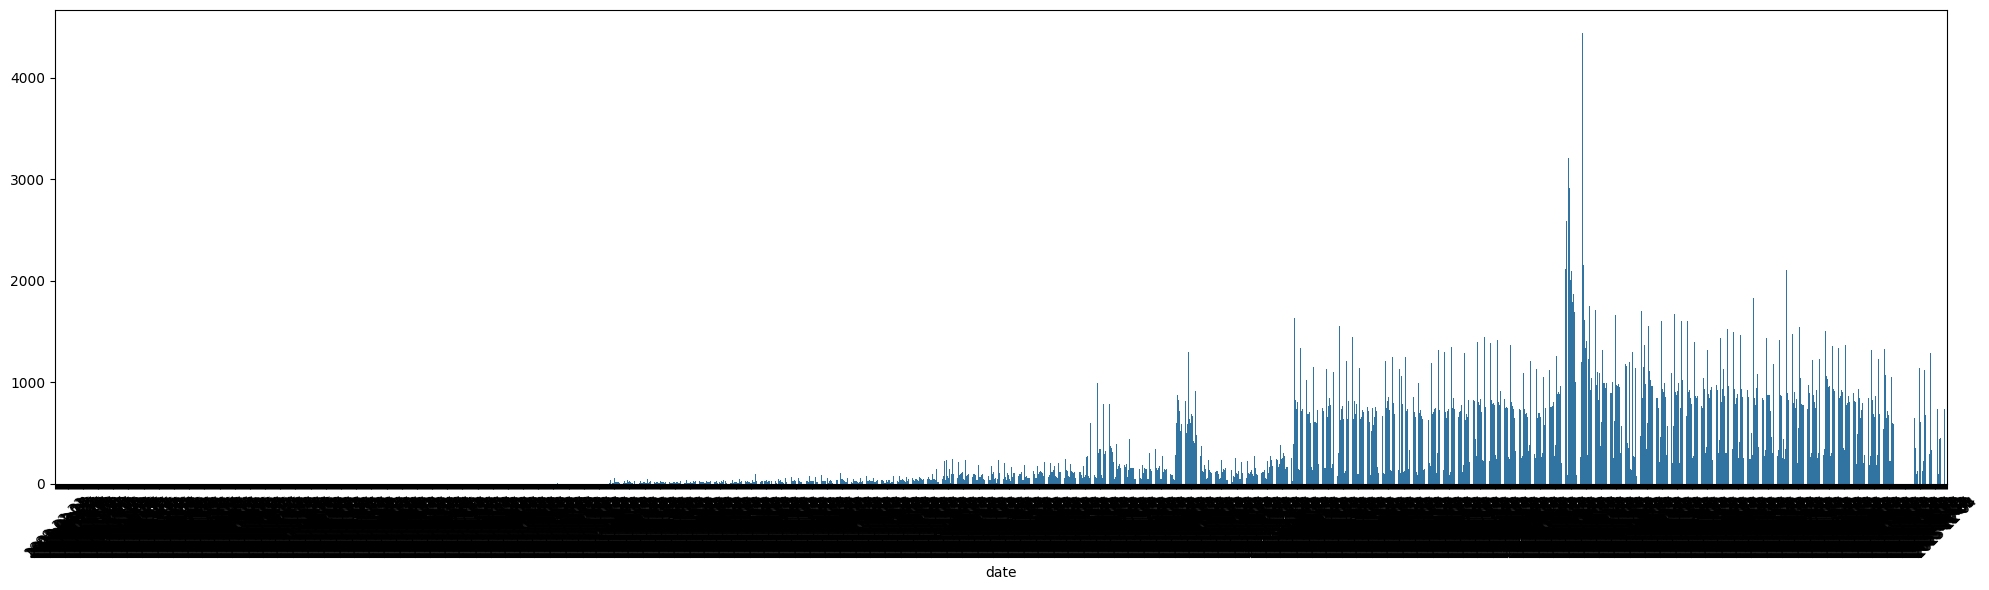

In [5]:
plt.figure(figsize=(20, 6))  # ← увеличил размер
sns.barplot(
    x=data_download.groupby('date')['uc__uc_id'].count().index,
    y=data_download.groupby('date')['uc__uc_id'].count().values
)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [6]:
data_download['date'].unique()

array([datetime.date(1899, 12, 31), datetime.date(2001, 1, 1),
       datetime.date(2008, 2, 1), ..., datetime.date(2025, 12, 2),
       datetime.date(2025, 12, 3), datetime.date(2025, 12, 4)],
      dtype=object)

In [7]:
data_download_srez = data_download[data_download['date'] >= pd.to_datetime('2022-01-01')]

/var/folders/yf/tnhxwgts2035718d0nhj30rw0000gn/T/ipykernel_32386/3955964194.py:1: FutureWarning: Comparison of Timestamp with datetime.date is deprecated in order to match the standard library behavior. In a future version these will be considered non-comparable. Use 'ts == pd.Timestamp(date)' or 'ts.date() == date' instead.
  data_download_srez = data_download[data_download['date'] >= pd.to_datetime('2022-01-01')]


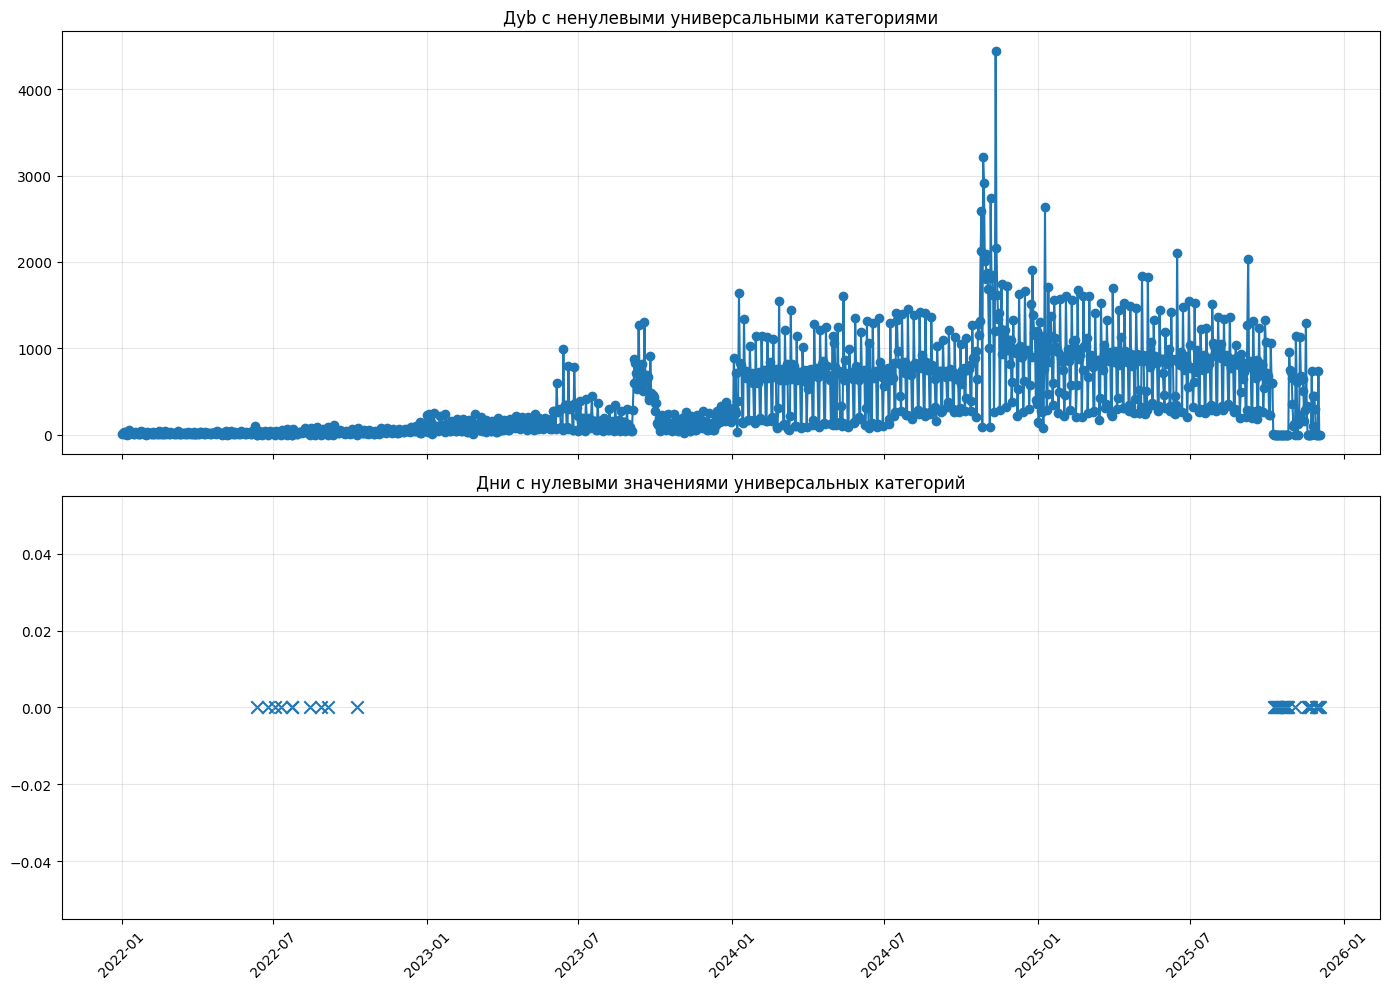

In [8]:
df = data_download_srez.groupby('date')['uc__uc_id'].count().reset_index()

# выделяем нулевые дни
zero_days = df[df['uc__uc_id'] == 0]

fig, axes = plt.subplots(2, 1, figsize=(14, 10), sharex=True)

# --- ГРАФИК 1 ---
axes[0].plot(df['date'], df['uc__uc_id'], marker='o')
axes[0].set_title("Дyb с ненулевыми универсальными категориями")
axes[0].grid(alpha=0.3)

# --- ГРАФИК 2 ---
axes[1].scatter(zero_days['date'], zero_days['uc__uc_id'], s=80, marker='x')
axes[1].set_title("Дни с нулевыми значениями универсальных категорий")
axes[1].grid(alpha=0.3)

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [9]:
# точно проверим дни в которых не было классификаций, чтобы потом проверит все значения, которые будут заполнены классами от своей модели
# все ненулевые дни заполнены с помощью yandexgpt

zero_dates = (
    data_download_srez
    .groupby('date')['uc__uc_id']
    .count()
    .reset_index()
)

zero_dates = zero_dates[zero_dates['uc__uc_id'] == 0]['date']

result = data_download_srez[data_download_srez['date'].isin(zero_dates)]
result_count = result.groupby('date')['date'].count()
result_count

date
2022-06-12       2
2022-06-25       2
2022-07-03       1
2022-07-10       2
2022-07-23       2
2022-07-24       3
2022-08-14       1
2022-08-27       2
2022-09-04       2
2022-10-09       1
2025-10-10     851
2025-10-11     220
2025-10-12     399
2025-10-13    1457
2025-10-14     901
2025-10-15    1007
2025-10-16    1052
2025-10-17    1061
2025-10-18     206
2025-10-19     370
2025-10-20    1497
2025-10-21     950
2025-10-22    1102
2025-10-23    1106
2025-10-24     918
2025-10-25     230
2025-10-26     603
2025-10-27    1765
2025-11-04     189
2025-11-19     791
2025-11-20     868
2025-11-21     598
2025-11-22     191
2025-11-23     253
2025-11-29     199
2025-11-30     303
2025-12-01     800
2025-12-03     540
2025-12-04       4
Name: date, dtype: int64

In [10]:
data_download_srez.uc__uc_id.isna().sum()

65656